# ResNet18 — multi-label classification experiment

Standalone notebook for **ResNet18** (`resnet18`). The steps are the same for every
architecture: split the data, freeze the backbone, augment, measure the
server F1, then read the error curves before touching the test set.

| | |
| --- | --- |
| Parameters | 11.7 M |
| Cost | 1.81 GFLOPS at 224 px |
| ImageNet top-1 | 69.8% |
| Starting batch | 128 |
| Learning rate, head only | 1e-3 |
| Learning rate, fine-tuning | 1e-4 |

Note: course baseline.

Torchvision weights: `ResNet18_Weights.DEFAULT`. The network returns logits;
the sigmoid is applied only when the metrics are computed.

1. Train / validation / local test split
2. Geometric and photometric augmentation
3. Baseline: frozen backbone, head only
4. Improved stage: stronger augmentation, dropout, weight decay, unfreeze
5. Local test, read once
6. Bias / variance diagnosis
7. Leaderboard submission, on unlabeled test images


## Configuration

`FULL_TRAIN = False` limits the run to 512 images and one epoch, to
check that the notebook runs from start to finish. Set it to `True` to run the
full experiment: 5 epochs with a frozen head, then 8 epochs of fine-tuning, on the
65,000 labeled images.

Asymmetric loss (`asl`) is the loss kept for the imbalance of the
80 classes. The error plotted below is **100 × (1 − server F1)**.


In [1]:
MODEL_NAME = 'resnet18'
FULL_TRAIN = True

SEED = 42
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
IMAGE_SIZE = 224
RESIZE_MODE = "pad"
LOSS = "asl"

BATCH_SIZE = 128
LR_HEAD = 1e-3
LR_FINETUNE = 1e-4
WEIGHT_DECAY_BASELINE = 0.0
WEIGHT_DECAY_FINETUNE = 1e-4
DROPOUT_FINETUNE = 0.3

# FULL_TRAIN runs the full setup (5 epochs with a frozen head, then 8 of fine-tuning).
# Otherwise: 512 images and 1 epoch, to check the pipeline.
EPOCHS_BASELINE = 5 if FULL_TRAIN else 1
EPOCHS_FINETUNE = 8 if FULL_TRAIN else 1
MAX_IMAGES = None if FULL_TRAIN else 512
NUM_WORKERS = 0


## Environment

The notebook adds `src/` to the path, sets the seed, and picks the GPU if it
is visible. Mixed precision is turned on only on CUDA.


In [2]:
import sys
from pathlib import Path

def _find_repo() -> Path:
    here = Path.cwd().resolve()
    for candidate in [here, *here.parents]:
        if (candidate / "src" / "coco_mlc").is_dir():
            return candidate
    raise FileNotFoundError(
        "Project root not found (folder src/coco_mlc). "
        "Run the notebook from the IAV_MS_COCO repository."
    )

REPO = _find_repo()
for _site in (REPO / ".venv").glob("Lib/site-packages"):
    if _site.is_dir() and str(_site) not in sys.path:
        sys.path.insert(0, str(_site))
for _site in (REPO / ".venv").glob("lib/python*/site-packages"):
    if _site.is_dir() and str(_site) not in sys.path:
        sys.path.insert(0, str(_site))
sys.path.insert(0, str(REPO / "src"))

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader
from torchinfo import summary

from coco_mlc.config import CLASSES, PATHS
from coco_mlc.data import (
    COCOTrainImageDataset,
    IMAGENET_MEAN,
    IMAGENET_STD,
    TransformSubset,
    build_transforms,
    get_three_way_split,
    load_label_matrix,
)
from coco_mlc.diagnostics import (
    diagnose_errors,
    error_percent,
    format_report,
    plot_error_curves,
    plot_model_diagram,
    save_history,
)
from coco_mlc.engine import describe_device, evaluate, fit_stage, pick_device, save_checkpoint
from coco_mlc.losses import build_criterion
from coco_mlc.metrics import all_metrics, format_metrics
from coco_mlc.models import (
    build_model,
    count_parameters,
    load_compatible_weights,
)
from coco_mlc.thresholds import tune_per_class_thresholds
from coco_mlc.utils import set_seed

set_seed(SEED)
device = pick_device()
USE_AMP = device.type == "cuda"
OUT_DIR = PATHS.outputs / "notebooks" / MODEL_NAME
OUT_DIR.mkdir(parents=True, exist_ok=True)
print(describe_device(device), "| amp" if USE_AMP else "| fp32")
print("Results:", OUT_DIR)


cuda (NVIDIA GeForce RTX 4060 Ti) | amp
Results: C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\outputs\notebooks\resnet18


C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Data preparation and split

The 65,000 labeled images are cut into three **stratified** and
disjoint sets (seed 42):

- **train (70%)** — learning the weights;
- **validation (15%)** — hyperparameters, early stop, thresholds;
- **local test (15%)** — generalization, read once at the end of the notebook.

The cache is `outputs/split_three_stratified_0.7_0.15_0.15_42.json`. It does
not replace the old 80/20 split. A run with `MAX_IMAGES` writes
a separate file, so the full split is not overwritten.

Rare classes (`hair drier`, `toaster`) dominate the server F1: the
table checks that they appear in all three sets.


In [3]:
PATHS.check()
ids, Y = load_label_matrix()
if MAX_IMAGES is not None:
    ids = ids[:MAX_IMAGES]
    Y = Y[:MAX_IMAGES]

cache_path = PATHS.outputs / f"split_three_stratified_0.7_0.15_0.15_{SEED}.json"
if MAX_IMAGES is not None:
    cache_path = cache_path.with_name(f"{cache_path.stem}_{len(Y)}{cache_path.suffix}")
train_idx, val_idx, test_idx = get_three_way_split(
    Y,
    val_fraction=VAL_FRACTION,
    test_fraction=TEST_FRACTION,
    seed=SEED,
    cache_path=cache_path,
)
train_set, val_set, test_set = set(train_idx), set(val_idx), set(test_idx)
assert train_set.isdisjoint(val_set)
assert train_set.isdisjoint(test_set)
assert val_set.isdisjoint(test_set)
assert len(train_set) + len(val_set) + len(test_set) == len(Y)

n = len(Y)
print(f"{n} labeled images")
for label, idx in ("train", train_idx), ("validation", val_idx), ("local test", test_idx):
    print(f"  {label:12s} {len(idx):6d}  ({100 * len(idx) / n:.1f} %)")

counts = pd.DataFrame({
    "class": list(CLASSES),
    "train": Y[train_idx].sum(axis=0),
    "validation": Y[val_idx].sum(axis=0),
    "test": Y[test_idx].sum(axis=0),
})
rare = counts[counts["class"].isin(["hair drier", "toaster", "person"])]
print()
print(rare.to_string(index=False))
print()
print("The official test set (images/test) has no labels: it is for the submission, not for this F1.")


65000 labeled images
  train         45525  (70.0 %)
  validation     9724  (15.0 %)
  local test     9751  (15.0 %)

     class  train  validation  test
    person  24846        5324  5324
   toaster     82          18    17
hair drier     72          15    15

The official test set (images/test) has no labels: it is for the submission, not for this F1.


## Data augmentation

The geometry stays in `pad` mode: a center crop would drop
objects whose label would still be positive. Two levels after that:

- **baseline** — horizontal flip;
- **improved stage** — rotation, translation, scale (`RandomAffine`) and
  photometric jitter (`ColorJitter`).

The validation, test, and train-evaluation loaders apply
no random transform. The train/validation gap then measures
generalization, not the noise of augmentation.


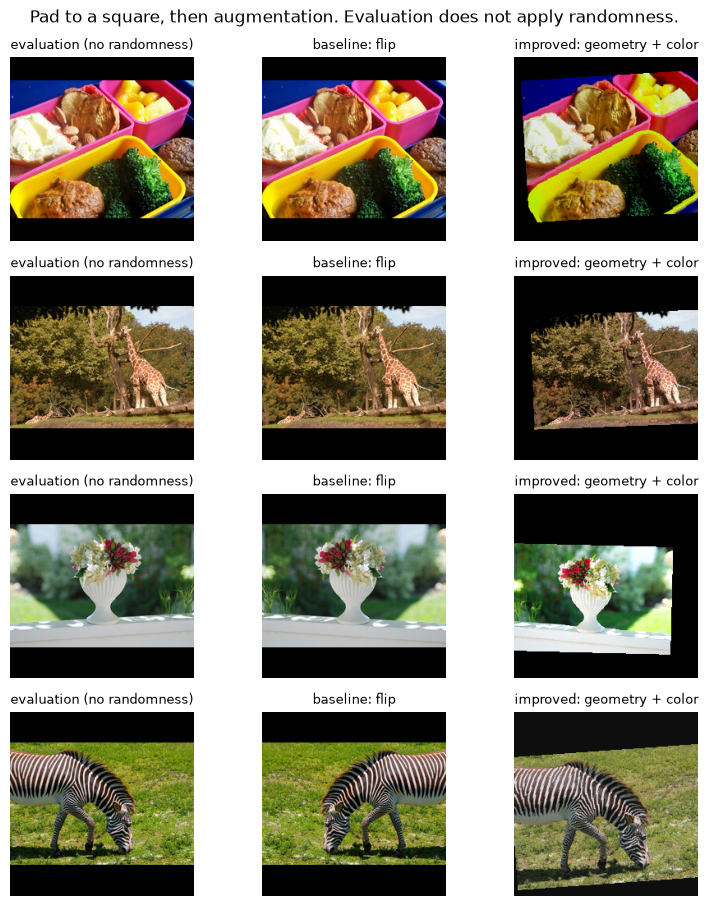

In [4]:
eval_tf = build_transforms(IMAGE_SIZE, train=False, resize_mode=RESIZE_MODE)
train_tf = build_transforms(IMAGE_SIZE, train=True, resize_mode=RESIZE_MODE, augment="flip")
experiment_tf = build_transforms(
    IMAGE_SIZE, train=True, resize_mode=RESIZE_MODE, augment="experiment",
)

preview = COCOTrainImageDataset(max_images=MAX_IMAGES)
mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

def show_tensor(ax, tensor, title):
    image = (tensor * std + mean).clamp(0, 1).permute(1, 2, 0).numpy()
    ax.imshow(image)
    ax.set_title(title, fontsize=9)
    ax.axis("off")

n_show = 4
fig, axes = plt.subplots(n_show, 3, figsize=(8, 2.3 * n_show))
for row in range(n_show):
    image, _labels = preview[row]
    show_tensor(axes[row, 0], eval_tf(image), "evaluation (no randomness)")
    show_tensor(axes[row, 1], train_tf(image), "baseline: flip")
    show_tensor(axes[row, 2], experiment_tf(image), "improved: geometry + color")
fig.suptitle("Pad to a square, then augmentation. Evaluation does not apply randomness.")
fig.tight_layout()
plt.show()


## Loaders

The local test loader is built here so it is not redefined later, but
no metric reads it before the generalization section.


In [5]:
base = COCOTrainImageDataset(max_images=MAX_IMAGES)

def make_loader(indices, transform, shuffle):
    return DataLoader(
        TransformSubset(base, indices, transform),
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        drop_last=shuffle and len(indices) >= 2 * BATCH_SIZE,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
        pin_memory=device.type == "cuda",
    )

train_loader = make_loader(train_idx, train_tf, shuffle=True)
train_eval_loader = make_loader(train_idx, eval_tf, shuffle=False)
val_loader = make_loader(val_idx, eval_tf, shuffle=False)
test_loader = make_loader(test_idx, eval_tf, shuffle=False)
print(
    f"batches train {len(train_loader)} | "
    f"train eval {len(train_eval_loader)} | "
    f"validation {len(val_loader)} | test {len(test_loader)}"
)


batches train 355 | train eval 356 | validation 76 | test 77


## Baseline — transfer learning

The ImageNet backbone is frozen. Only the linear head, reset to
80 logits, is trained. The output bias starts from the log-odds of the
**train** prevalences (not validation, not test).

The diagram separates preprocessing, the frozen backbone, and the
trainable head. The `torchinfo` table lists the blocks of the fine-tuned network.


11.2 M parameters, of which 0.041 M are trainable (the head)


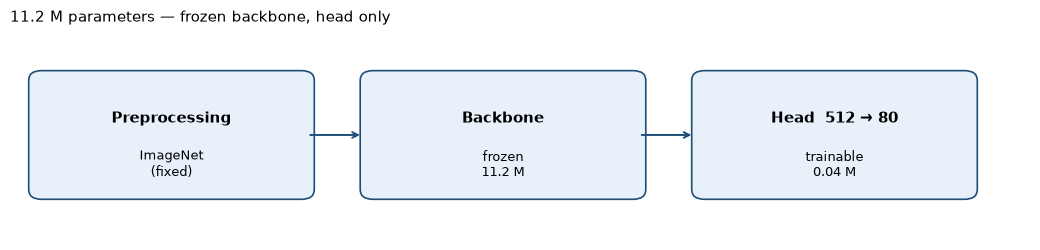

Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [1, 80]                   --
├─Conv2d: 1-1                            [1, 64, 112, 112]         (9,408)
├─BatchNorm2d: 1-2                       [1, 64, 112, 112]         (128)
├─ReLU: 1-3                              [1, 64, 112, 112]         --
├─MaxPool2d: 1-4                         [1, 64, 56, 56]           --
├─Sequential: 1-5                        [1, 64, 56, 56]           --
│    └─BasicBlock: 2-1                   [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-1                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-2             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-3                    [1, 64, 56, 56]           --
│    │    └─Conv2d: 3-4                  [1, 64, 56, 56]           (36,864)
│    │    └─BatchNorm2d: 3-5             [1, 64, 56, 56]           (128)
│    │    └─ReLU: 3-6                    [1, 64, 56, 56]   

In [6]:
prior = Y[train_idx].mean(axis=0)
model_baseline = build_model(
    MODEL_NAME,
    pretrained=True,
    freeze_backbone=True,
    dropout=0.0,
    prior=prior,
).to(device)

total, trainable = count_parameters(model_baseline)
print(f"{total / 1e6:.1f} M parameters, of which {trainable / 1e6:.3f} M are trainable (the head)")
fig = plot_model_diagram(model_baseline, frozen=True)
plt.show()
summary(model_baseline, input_size=(1, 3, IMAGE_SIZE, IMAGE_SIZE), depth=3)


## Head training

AdamW, learning rate `LR_HEAD`, no weight decay. The cosine scheduler is set from
the number of mini-batches in this stage. At each epoch we record
precision, recall, and F1, on the train set **without** augmentation and on
validation, at the fixed threshold 0.5.


  epoch  1/5  train_loss=0.0343  val_loss=0.0285  P/R/F1 train=0.186/0.680/0.292  val=0.178/0.642/0.278  error train=70.83%  val=72.16%


  epoch  2/5  train_loss=0.0284  val_loss=0.0281  P/R/F1 train=0.184/0.725/0.293  val=0.169/0.643/0.268  error train=70.68%  val=73.25%


  epoch  3/5  train_loss=0.0275  val_loss=0.0274  P/R/F1 train=0.225/0.659/0.335  val=0.179/0.619/0.277  error train=66.48%  val=72.27%


  epoch  4/5  train_loss=0.0269  val_loss=0.0273  P/R/F1 train=0.187/0.731/0.298  val=0.171/0.651/0.271  error train=70.22%  val=72.86%


  epoch  5/5  train_loss=0.0266  val_loss=0.0273  P/R/F1 train=0.185/0.747/0.297  val=0.169/0.653/0.269  error train=70.29%  val=73.10%


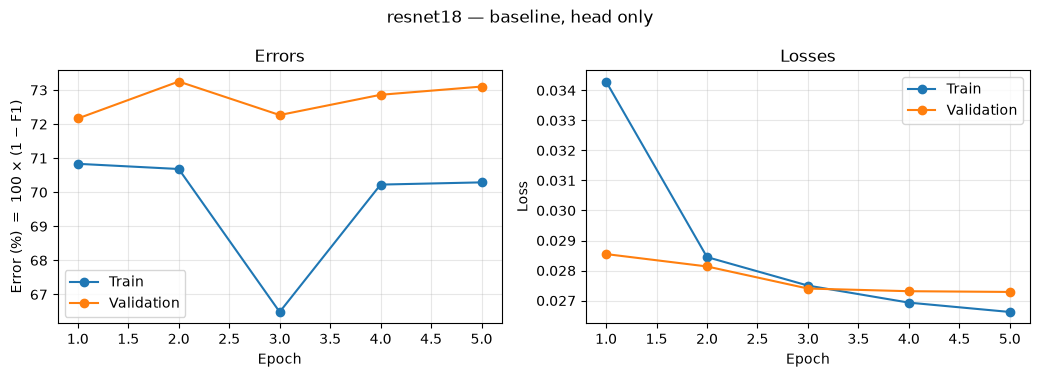

Last epoch (threshold 0.5) — precision train/val 0.185/0.169 | recall 0.747/0.653 | F1 0.297/0.269


In [7]:
criterion = build_criterion(LOSS)
optimizer = torch.optim.AdamW(
    [p for p in model_baseline.parameters() if p.requires_grad],
    lr=LR_HEAD,
    weight_decay=WEIGHT_DECAY_BASELINE,
)
baseline_steps = EPOCHS_BASELINE * max(len(train_loader), 1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max(baseline_steps, 1))

history_baseline = fit_stage(
    model_baseline,
    train_loader,
    train_eval_loader,
    val_loader,
    criterion,
    optimizer,
    device,
    EPOCHS_BASELINE,
    scheduler=scheduler,
    amp=USE_AMP,
    desc="baseline",
)
save_history(history_baseline, OUT_DIR / "history_baseline.csv")
save_checkpoint(OUT_DIR / "baseline.pth", model_baseline, {
    "kind": "notebook_baseline",
    "backbone": MODEL_NAME,
    "freeze_backbone": True,
    "dropout": 0.0,
    "loss": LOSS,
    "image_size": IMAGE_SIZE,
    "resize_mode": RESIZE_MODE,
    "seed": SEED,
})

fig = plot_error_curves(history_baseline, title=f"{MODEL_NAME} — baseline, head only")
plt.show()
last_baseline = history_baseline[-1]
print(
    "Last epoch (threshold 0.5) — "
    f"precision train/val {last_baseline['train_precision']:.3f}/{last_baseline['val_precision']:.3f} | "
    f"recall {last_baseline['train_recall']:.3f}/{last_baseline['val_recall']:.3f} | "
    f"F1 {last_baseline['train_f1']:.3f}/{last_baseline['val_f1']:.3f}"
)


## Improved stage

Three levers, in this cell, so they can be changed together or
commented out one by one:

- `experiment` augmentation instead of a simple flip;
- dropout on the head and weight decay (L2 penalty);
- unfreeze the whole network, with a smaller learning rate.

Baseline weights are copied, including the head already adapted to the
80 classes. The local test still does not enter the decisions.


Tensors copied from the baseline: 122
11.2 M parameters, of which 11.2 M are trainable


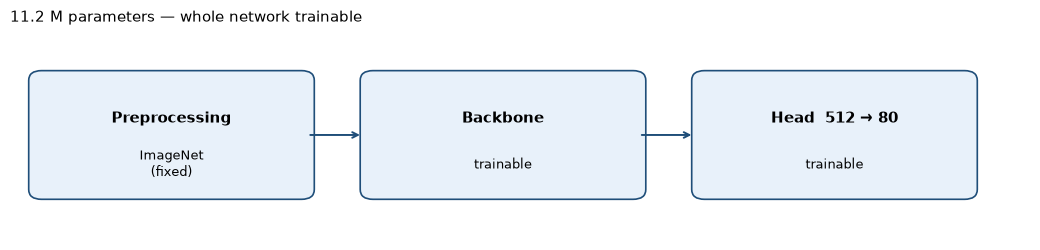

  epoch  1/8  train_loss=0.0315  val_loss=0.0247  P/R/F1 train=0.247/0.698/0.364  val=0.226/0.653/0.336  error train=63.55%  val=66.38%


  epoch  2/8  train_loss=0.0283  val_loss=0.0239  P/R/F1 train=0.265/0.689/0.383  val=0.234/0.635/0.342  error train=61.73%  val=65.78%


  epoch  3/8  train_loss=0.0269  val_loss=0.0231  P/R/F1 train=0.272/0.746/0.399  val=0.244/0.668/0.357  error train=60.13%  val=64.26%


  epoch  4/8  train_loss=0.0258  val_loss=0.0235  P/R/F1 train=0.270/0.794/0.403  val=0.241/0.714/0.361  error train=59.70%  val=63.95%


  epoch  5/8  train_loss=0.0248  val_loss=0.0225  P/R/F1 train=0.286/0.787/0.419  val=0.257/0.704/0.377  error train=58.06%  val=62.30%


  epoch  6/8  train_loss=0.0241  val_loss=0.0223  P/R/F1 train=0.304/0.787/0.439  val=0.267/0.696/0.386  error train=56.12%  val=61.39%


  epoch  7/8  train_loss=0.0236  val_loss=0.0223  P/R/F1 train=0.304/0.784/0.438  val=0.267/0.688/0.384  error train=56.22%  val=61.57%


  epoch  8/8  train_loss=0.0234  val_loss=0.0224  P/R/F1 train=0.300/0.797/0.436  val=0.267/0.700/0.387  error train=56.36%  val=61.31%


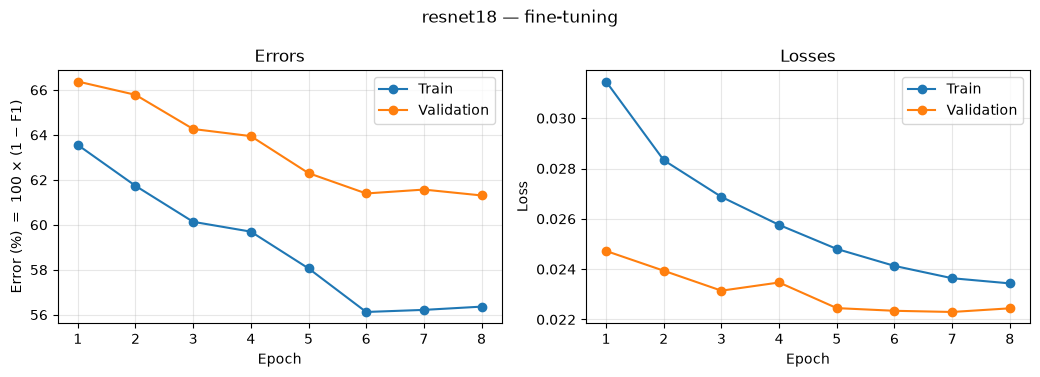

Last epoch (threshold 0.5) — precision train/val 0.300/0.267 | recall 0.797/0.700 | F1 0.436/0.387


In [8]:
train_loader_ft = make_loader(train_idx, experiment_tf, shuffle=True)
model_ft = build_model(
    MODEL_NAME,
    pretrained=True,
    freeze_backbone=False,
    dropout=DROPOUT_FINETUNE,
    prior=prior,
).to(device)
copied = load_compatible_weights(model_ft, model_baseline)
print(f"Tensors copied from the baseline: {len(copied)}")

total_ft, trainable_ft = count_parameters(model_ft)
print(f"{total_ft / 1e6:.1f} M parameters, of which {trainable_ft / 1e6:.1f} M are trainable")
fig = plot_model_diagram(model_ft, frozen=False)
plt.show()

optimizer_ft = torch.optim.AdamW(
    model_ft.parameters(),
    lr=LR_FINETUNE,
    weight_decay=WEIGHT_DECAY_FINETUNE,
)
finetune_steps = EPOCHS_FINETUNE * max(len(train_loader_ft), 1)
scheduler_ft = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ft, T_max=max(finetune_steps, 1),
)
history_ft = fit_stage(
    model_ft,
    train_loader_ft,
    train_eval_loader,
    val_loader,
    criterion,
    optimizer_ft,
    device,
    EPOCHS_FINETUNE,
    scheduler=scheduler_ft,
    amp=USE_AMP,
    desc="fine-tuning",
)
save_history(history_ft, OUT_DIR / "history_finetune.csv")
save_checkpoint(OUT_DIR / "finetune.pth", model_ft, {
    "kind": "notebook_finetune",
    "backbone": MODEL_NAME,
    "freeze_backbone": False,
    "dropout": DROPOUT_FINETUNE,
    "loss": LOSS,
    "image_size": IMAGE_SIZE,
    "resize_mode": RESIZE_MODE,
    "seed": SEED,
})

fig = plot_error_curves(history_ft, title=f"{MODEL_NAME} — fine-tuning")
plt.show()
last_ft = history_ft[-1]
print(
    "Last epoch (threshold 0.5) — "
    f"precision train/val {last_ft['train_precision']:.3f}/{last_ft['val_precision']:.3f} | "
    f"recall {last_ft['train_recall']:.3f}/{last_ft['val_recall']:.3f} | "
    f"F1 {last_ft['train_f1']:.3f}/{last_ft['val_f1']:.3f}"
)


## Generalization — local test, read once

Per-class thresholds are calibrated **only** on validation, then
applied to train, validation, and test. The test set is not used to choose
the threshold. Network scores are computed only once per set.


In [9]:
def collect(loader, net, desc):
    results, _per_class, scores, targets = evaluate(
        loader, net, criterion, device,
        thresholds=0.5, return_scores=True, amp=USE_AMP, desc=desc,
    )
    return results, scores, targets

train_05, train_scores, train_targets = collect(train_eval_loader, model_ft, "train")
val_05, val_scores, val_targets = collect(val_loader, model_ft, "validation")
test_05, test_scores, test_targets = collect(test_loader, model_ft, "local test")

thresholds, _f1_val, _hist = tune_per_class_thresholds(val_scores, val_targets)

def at(scores, targets, th):
    return all_metrics(scores, targets, thresholds=th)

train_cal = at(train_scores, train_targets, thresholds)
val_cal = at(val_scores, val_targets, thresholds)
test_cal = at(test_scores, test_targets, thresholds)

rows = []
for split, raw, calibrated in (
    ("train", train_05, train_cal),
    ("validation", val_05, val_cal),
    ("local test", test_05, test_cal),
):
    rows.append({
        "split": split,
        "precision @0.5": raw["precision"],
        "recall @0.5": raw["recall"],
        "F1 @0,5": raw["f1"],
        "error @0.5 (%)": error_percent(raw["f1"]),
        "calibrated precision": calibrated["precision"],
        "calibrated recall": calibrated["recall"],
        "calibrated F1": calibrated["f1"],
        "calibrated error (%)": error_percent(calibrated["f1"]),
    })
report = pd.DataFrame(rows).set_index("split")
print(report.round(4).to_string())
print()
print("Calibrated validation:", format_metrics(val_cal))
print("Calibrated local test:", format_metrics(test_cal))
report.to_csv(OUT_DIR / "generalization.csv")


  pass 1: validation F1 = 0.6146
  pass 2: validation F1 = 0.6158
  pass 3: validation F1 = 0.6158
  pass 4: validation F1 = 0.6158
            precision @0.5  recall @0.5  F1 @0,5  error @0.5 (%)  calibrated precision  calibrated recall  calibrated F1  calibrated error (%)
split                                                                                                                                         
train               0.3004       0.7974   0.4364         56.3601                0.6110             0.6685         0.6385               36.1506
validation          0.2673       0.7002   0.3869         61.3069                0.5961             0.6369         0.6158               38.4194
local test          0.2645       0.6948   0.3831         61.6874                0.5732             0.6195         0.5954               40.4560

Calibrated validation: f1=0.6158 | precision=0.5961 | recall=0.6369 | accuracy=0.6717 | macro_f1=0.5281 | micro_f1=0.4652 | mAP=0.6312
Calibrated local 

## Diagnosis

The error is **100 × (1 − server F1)**. We first compare train and
validation. The test set comes in only after that.

- **Underfitting (high bias).** Errors are high and close, for example
  10% on train and 12% on validation. Ideas: a larger network,
  train longer, change the optimizer, hyperparameter search.
- **Overfitting (high variance).** A large gap, for example 1% on train
  and 10% on validation. Ideas: a larger and more varied train set, stronger
  augmentation, regularization (L2, dropout), hyperparameter search.
- **Both.** High errors and a large gap, for example 10% and 20%.
  Apply both lists of actions.
- **Ideal model.** Very low and close errors, for example 0.5% and 1%.
- **Poor generalization to the test set.** The local test is clearly worse than
  validation. Build a larger and more varied validation set: the
  validation set was overfit. Do not retune hyperparameters on this test set.

A gap that matches none of these regimes is reported as an intermediate
case. The printout summarizes the three stages, then the ideas of the last
case only. The detail is saved in
`outputs/notebooks/<architecture>/diagnosis.json`.


In [10]:
import importlib
import json

import coco_mlc.diagnostics as _diagnostics

importlib.reload(_diagnostics)
diagnose_errors = _diagnostics.diagnose_errors
format_report = _diagnostics.format_report

def _last_epoch(row):
    return {
        "precision_train": row["train_precision"],
        "precision_val": row["val_precision"],
        "recall_train": row["train_recall"],
        "recall_val": row["val_recall"],
        "f1_train": row["train_f1"],
        "f1_val": row["val_f1"],
    }

diagnosis = {
    "notebook": f"exp_{MODEL_NAME}.ipynb",
    "model": MODEL_NAME,
    "baseline_threshold_0_5": {
        "last_epoch": _last_epoch(last_baseline),
        "diagnosis": diagnose_errors(
            last_baseline["train_error"],
            last_baseline["val_error"],
        ),
    },
    "finetune_threshold_0_5": {
        "last_epoch": _last_epoch(last_ft),
        "diagnosis": diagnose_errors(
            last_ft["train_error"],
            last_ft["val_error"],
            test_error=error_percent(test_05["f1"]),
        ),
    },
    "calibrated": {
        "diagnosis": diagnose_errors(
            error_percent(train_cal["f1"]),
            error_percent(val_cal["f1"]),
            test_error=error_percent(test_cal["f1"]),
        ),
    },
}
diagnosis_path = OUT_DIR / "diagnosis.json"
diagnosis_path.write_text(
    json.dumps(diagnosis, indent=2, ensure_ascii=False),
    encoding="utf-8",
)
print(format_report([
    ("Baseline, threshold 0.5", diagnosis["baseline_threshold_0_5"]["diagnosis"]),
    ("Fine-tuning, threshold 0.5", diagnosis["finetune_threshold_0_5"]["diagnosis"]),
    ("Calibrated thresholds", diagnosis["calibrated"]["diagnosis"]),
]))
print()
print("Saved:", diagnosis_path)


Baseline, threshold 0.5
Underfitting (high bias)
F1 train 0.297 | validation 0.269
Train error 70.3% | validation 73.1% | gap +2.8 pts
Errors are high and close: the model has not learned enough yet.

Fine-tuning, threshold 0.5
Intermediate case
F1 train 0.436 | validation 0.387 | test 0.383
Train error 56.4% | validation 61.3% | gap +4.9 pts
Test 61.7% | gap with validation +0.4 pts
Neither the level nor the gap matches one of the four typical examples.

Calibrated thresholds
Underfitting (high bias)
F1 train 0.638 | validation 0.616 | test 0.595
Train error 36.2% | validation 38.4% | gap +2.3 pts
Test 40.5% | gap with validation +2.0 pts
Errors are high and close: the model has not learned enough yet.

Suggested next steps
- Use a larger network (more layers or more units).
- Train for longer.
- Change the optimizer.
- Run a hyperparameter search.

Saved: C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\outputs\notebooks\resnet18\diagnosis.json


## Submission — leaderboard

The local test has labels: it measures generalization, and it is not sent
to the server. This cell runs the fine-tuned network on the images in
`images/test`, with the thresholds calibrated on validation only.

The JSON follows the leaderboard format: one key per image (12 digits, no
extension), a list of class indices. It is written to
`submissions/exp_<architecture>.json`.


In [11]:
import json
import re

import torch
from coco_mlc.data import COCOTestImageDataset
from coco_mlc.thresholds import apply_thresholds

server_set = COCOTestImageDataset(transform=eval_tf)
server_loader = DataLoader(
    server_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=device.type == "cuda",
)

chunks = []
model_ft.eval()
with torch.inference_mode():
    for images, _stems in server_loader:
        images = images.to(device, non_blocking=True)
        with torch.autocast(device_type=device.type, enabled=USE_AMP):
            logits = model_ft(images)
        chunks.append(torch.sigmoid(logits.float()).cpu())
server_scores = torch.cat(chunks)
decisions = apply_thresholds(server_scores, thresholds, min_labels=1)

predictions = {
    str(image_id): [int(c) for c in torch.nonzero(row, as_tuple=False).flatten().tolist()]
    for image_id, row in zip(server_set.ids, decisions)
}

problems = []
if len(predictions) != len(server_set):
    problems.append(f"{len(predictions)} entries instead of {len(server_set)}")
bad_ids = [key for key in predictions if re.fullmatch(r"\d{12}", key) is None]
if bad_ids:
    problems.append(f"ids do not match the expected pattern (e.g. {bad_ids[:3]})")
empty = [key for key, labels in predictions.items() if not labels]
if empty:
    problems.append(f"{len(empty)} empty lists")
bad_values = [
    key for key, labels in predictions.items()
    if not all(isinstance(c, int) and 0 <= c < len(CLASSES) for c in labels)
]
if bad_values:
    problems.append(f"indices outside [0, {len(CLASSES) - 1}]")
if problems:
    raise RuntimeError("Submission is not valid: " + "; ".join(problems))

PATHS.submissions.mkdir(parents=True, exist_ok=True)
submission_path = PATHS.submissions / f"exp_{MODEL_NAME}.json"
submission_path.write_text(json.dumps(predictions, indent=2), encoding="utf-8")
mean_labels = sum(len(labels) for labels in predictions.values()) / len(predictions)
print(f"Submission: {submission_path}")
print(f"{len(predictions)} images | {mean_labels:.2f} classes per image on average")


Submission: C:\Users\trans\OneDrive\Documents\INSA Lyon\5TCA\IAV\IAV_MS_COCO\submissions\exp_resnet18.json
4952 images | 5.59 classes per image on average


## Résultats — leaderboard

![Mean metrics](../../../results/leaderboard/exp_resnet18.png)